# Part C: Representation and Clustering

In [36]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
import time

digits = load_digits()

X = digits.data
y_true = digits.target

#raw
start_time = time.time()
model_raw = KMeans(
    n_clusters=10,
    n_init=10,
    random_state=47,
)

labels_raw = model_raw.fit_predict(X)

run_time_raw = time.time() - start_time
ari_raw = adjusted_rand_score(y_true, labels_raw)
nmi_raw = normalized_mutual_info_score(y_true, labels_raw)
silhouette_raw = silhouette_score(X, labels_raw)

print("Raw features")
print(f"ARI: {ari_raw:.4f}")
print(f"NMI: {nmi_raw:.4f}")
print(f"Silhouette: {silhouette_raw:.4f}")
print(f"Run time: {run_time_raw:.4f}s")



Raw features
ARI: 0.6677
NMI: 0.7431
Silhouette: 0.1824
Run time: 0.0481s


In [35]:
#Standardized
start_time = time.time()
X_scaled = StandardScaler().fit_transform(X)
model_scaled = KMeans(
    n_clusters=10,
    n_init=10,
    random_state=47,
)
labels_scaled = model_scaled.fit_predict(X_scaled)

run_time = time.time() - start_time
ari_scaled = adjusted_rand_score(y_true, labels_scaled)
nmi_scaled = normalized_mutual_info_score(y_true, labels_scaled)
silhouette_scaled = silhouette_score(X_scaled, labels_scaled)

print("Standardized features")
print(f"ARI: {ari_scaled:.4f}")
print(f"NMI: {nmi_scaled:.4f}")
print(f"Silhouette: {silhouette_scaled:.4f}")
print(f"Run time: {run_time:.4f}s")

Standardized features
ARI: 0.4607
NMI: 0.6142
Silhouette: 0.1417
Run time: 0.0447s


In [34]:
#PCA
for dimension in [2, 10, 20]:
    start = time.perf_counter()

    pca = PCA(n_components=dimension, random_state=47)
    X_pca = pca.fit_transform(X)

    model = KMeans(
        n_clusters=10,
        n_init=10,
        random_state=47,
    )
    labels = model.fit_predict(X_pca)

    runtime = time.perf_counter() - start

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    silhouette = silhouette_score(X_pca, labels)

    print(
        f"PCA dimension={dimension}, "
        f"ARI={ari:.4f}, "
        f"NMI={nmi:.4f}, "
        f"Silhouette={silhouette:.4f}, "
        f"Runtime={runtime:.4f}s"
    )



PCA dimension=2, ARI=0.3952, NMI=0.5271, Silhouette=0.3932, Runtime=0.0485s
PCA dimension=10, ARI=0.6531, NMI=0.7285, Silhouette=0.2642, Runtime=0.0350s
PCA dimension=20, ARI=0.6636, NMI=0.7374, Silhouette=0.2125, Runtime=0.0285s


In [ ]:
pca2 = PCA(n_components=2, random_state=47)
X_pca2 = pca2.fit_transform(X)

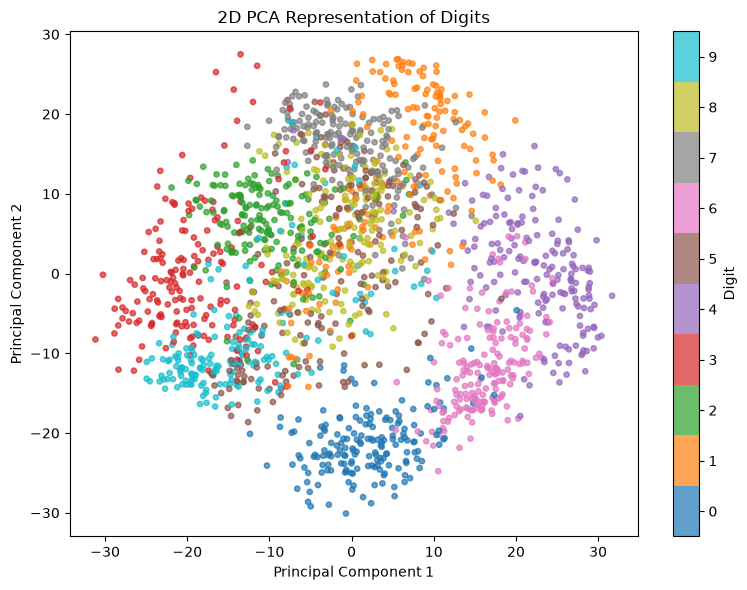

In [37]:
#visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca2[:, 0],       # 第一主成分，作为横坐标
    X_pca2[:, 1],       # 第二主成分，作为纵坐标
    c=y_true,          # 按真实数字类别着色
    cmap="tab10",
    s=15,
    alpha=0.7,
    vmin=-0.5,
    vmax=9.5,
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Representation of Digits")
plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.tight_layout()
plt.show()

Explain why changing the representation can change the clustering result even when the clustering algorithm is unchanged.

Ans: K-means groups samples based on Euclidean distance. Changing the representation can change these distances and therefore change the clustering result.